In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [2]:
#import sql database

conn= sqlite3.connect('customer_churn.db')

sql_query= """
select name 
from sqlite_master
where type="table"
"""
tables= pd.read_sql(sql_query,conn)

#creating database for each table

for table_name in tables['name']:
    df=pd.read_sql(f"select * from {table_name}",conn)
    globals()[f"df_{table_name}"]=df
    print(f"Dataframe created: df_{table_name}")
conn.close()

Dataframe created: df_db_customer
Dataframe created: df_db_subscription
Dataframe created: df_db_support


In [3]:
#1. Data cleaning

In [4]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [5]:
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,None,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,None,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,None,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,None,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,None,None


In [6]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [7]:
## a. renaming name column
## b. drop columns interest and pincode (not required)
## c. changing datatype of dob
## d. Data standardization of gender
## e. handling missing values in country

In [8]:
# renaming column

df_db_customer.rename(columns={'name':'customer_name'},inplace=True)

In [9]:
## b. drop columns interest and pincode (not required)

df_db_customer.drop(columns=['interests','pincode'],inplace=True)

In [10]:
## c. changing datatype of dob

df_db_customer['dob']=pd.to_datetime(df_db_customer['dob'])

In [11]:
## data standardization - gender

df_db_customer['gender'].unique()

array(['Male', 'Female', 'Women', 'Men'], dtype=object)

In [12]:
df_db_customer['gender']=df_db_customer['gender'].replace({'Men':'Male','Women':'Female'})

In [13]:
# handling miswsing values in - country

df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [14]:
state_country_mapping= df_db_customer.dropna(subset='country').set_index('state')['country'].to_dict()
df_db_customer['country']=df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [15]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [16]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [17]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [18]:
# changing data type- subscription_start_date , renewal_date , cancellation_date

df_db_subscription['subscription_start_date']=pd.to_datetime(df_db_subscription['subscription_start_date'])


In [19]:
df_db_subscription['renewal_date']=pd.to_datetime(df_db_subscription['renewal_date'])


In [20]:
df_db_subscription['cancellation_date']=pd.to_datetime(df_db_subscription['cancellation_date'])


In [21]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [22]:
df_db_support.tail()

,customerid,complaint_date,escalations,csat_score,col_1,comment
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None
5,0017-IUDMW,2024-04-10 00:00:00,Y,25,None,None
6,0019-EFAEP,2024-09-27 00:00:00,Y,30,None,None
7,0022-TCJCI,2024-09-13 00:00:00,Y,10,None,None
8,0022-TCJCI,2024-09-14 00:00:00,N,90,None,received refund


In [23]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [24]:
# drop cloumns -col_1, comment
# change datatype- complaint_date

In [25]:
df_db_support.drop(['col_1','comment'],axis=1,inplace=True)

In [26]:
df_db_support['complaint_date']=pd.to_datetime(df_db_support['complaint_date'])

In [27]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 420.0+ bytes


In [28]:
#2. Feature engineering and data analysis

In [29]:
# create a new column using existing column- churn flag

df_db_subscription.head()
df_db_subscription['churn_flag']=np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [30]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [31]:
# joining all the three tables, first need to fix support table

df=(df_db_subscription.merge(df_db_customer,on='customerid',how='left').merge(df_db_support,on='customerid',how='left'))

In [32]:
df.shape

(23, 20)

In [33]:
df_db_subscription.shape

(21, 12)

In [34]:
df_db_customer.shape

(21, 6)

In [35]:
df_db_support.shape

(9, 4)

In [36]:
df_db_support['customerid'].nunique()

7

In [37]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [38]:
df_db_support['count']=df_db_support.groupby('customerid')['customerid'].transform('count')

In [39]:
df_db_support

,customerid,complaint_date,escalations,csat_score,count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
5,0017-IUDMW,2024-04-10,Y,25,1
6,0019-EFAEP,2024-09-27,Y,30,1
7,0022-TCJCI,2024-09-13,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2


In [40]:
df_db_support=df_db_support.sort_values('complaint_date').drop_duplicates('customerid',keep='last')

In [41]:
df_db_support['customerid'].shape

(7,)

In [42]:
# merge after fixing

df=(df_db_subscription.merge(df_db_customer,on='customerid',how='left').merge(df_db_support,on='customerid',how='left'))

In [43]:
df.shape

(21, 21)

In [44]:
#Data analysis

In [45]:
df.to_csv("churn.csv",index='false')

In [46]:
#1. Churn Rate

churn_rate=df['churn_flag'].mean()*100
print("Churn Rate=",round(churn_rate,2))

Churn Rate= 28.57


In [47]:
#2. Retention Rate

retention_rate=100-round(churn_rate,2)
print('Retention Rate=',retention_rate)

Retention Rate= 71.43


In [48]:
#3. churn by plan type

churn_by_plantype=df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name="churn_rate_%")
churn_by_plantype

,plan_type,churn_rate_%
0,Basic,60.00
1,Premium,14.29
2,Standard,22.22


In [49]:
#4. churn by state+sum(revenue)+count of users

churn_by_state=df.groupby('state').agg(
    churn_rate=('churn_flag', 'mean'),
    total_revenue=('monthly_charges', 'sum'),
    user_count=('customerid', 'nunique')
)
churn_by_state


,churn_rate,total_revenue,user_count
state,,,
Delhi,0.250000,52.96,4
Karnataka,1.000000,20.98,2
Kathmandu,0.000000,20.98,2
Maharashtra,0.000000,50.97,3
Meghalaya,0.666667,42.97,3
Nagaland,0.000000,22.99,1
Rajasthan,0.000000,36.98,2
Telangana,0.500000,30.98,2
Uttar Pradesh,0.000000,115.98,2


In [50]:
#4. Churn  by subscirption type+sum(revenue)+count of users

churn_by_suscription_type=df.groupby('subscription_type').agg(
    churn_rate=('churn_flag','mean'),
    total_revenue=('monthly_charges','sum'),
    user_count=('customerid','nunique')
)
churn_by_suscription_type

,churn_rate,total_revenue,user_count
subscription_type,,,
Organic,0.000000,145.91,9
Paid,0.166667,174.94,6
Refferal,0.833333,74.94,6


In [51]:
#5. ARPU - average revenue per user

ARPU=df['monthly_charges'].mean().round(2)
ARPU


18.85

In [52]:
#6. average customer tenure
today=pd.Timestamp.today()
df['tenure_days']=np.where(
    df['cancellation_date'].notna(),
    (df['cancellation_date']-df['subscription_start_date']).dt.days,
    (today-df['subscription_start_date']).dt.days
)
avg_tenure=df['tenure_days'].mean().round(2)
print("Average tenure per user",avg_tenure)

Average tenure per user 1550.14


In [53]:
#7. revenue at risk- revenue loss after churned

revenue_at_risk=df.loc[df['churn_flag']==1,'monthly_charges'].sum()
print("Rvenue loss after churn=",revenue_at_risk)

Rvenue loss after churn= 73.94


In [54]:
 #8. escalations rate

escalation_rate=(df['escalations']=='Y').mean()*100
print('Escalaton Rate=',round(escalation_rate,2))

Escalaton Rate= 19.05


In [55]:
#9. Fiding correlation between churn and escalations

df['escalations']=np.where((df['escalations'])=='Y',1,0)
df['escalations']

0     0
1     1
2     0
3     0
4     1
5     0
6     0
7     0
8     0
9     0
10    0
11    1
12    0
13    1
14    0
15    0
16    0
17    0
18    0
19    0
20    0
Name: escalations, dtype: int32

In [56]:
correlation=df['escalations'].corr(df['churn_flag'])
print("Correlation =", round(correlation, 2))

Correlation = 0.77


In [57]:
#10. average complaint per user

avg_complaint=(df['count'].sum()/df['customerid'].nunique())*100
print("Average complaint per user",round(avg_complaint,2))

Average complaint per user 42.86


In [58]:
#11. Understanding churn score

conditions=[
    df['churn_score']>70,
    ((df['churn_score']>50) & (df['churn_score']<=70)),
    df['churn_score']<=50
]
output=['high','mid','low']
df['churn_risk']=np.select(conditions,output,default='unknown')

In [59]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'count', 'tenure_days',
       'churn_risk'],
      dtype='object')

In [60]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,count,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,2025.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0,high


In [61]:
# Data visualization


In [62]:
df_visual=df.copy()

In [63]:
df_visual.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,count,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,2025.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,India,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1410.0,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,India,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,2700.0,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,India,Delhi,Female,1990-05-05,2024-01-20,1,20.0,1.0,419.0,high


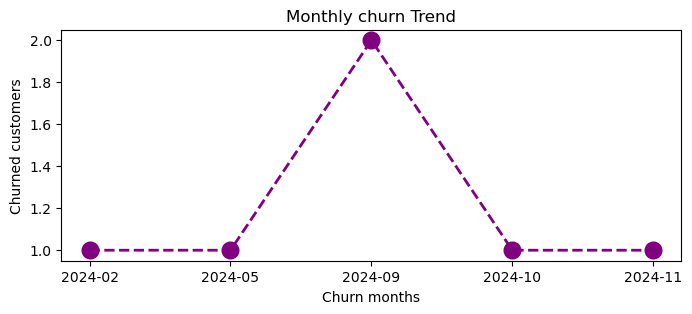

In [71]:
#1. Monthly Churn Trend

df_visual['cancellation_month']=df_visual['cancellation_date'].dt.to_period('M')
churn_trend=df_visual[df_visual['churn_flag']==1].groupby('cancellation_month').size()

plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype('str'),churn_trend.values,color='purple', marker='o', linestyle='dashed', linewidth=2, markersize=12)

plt.title("Monthly churn Trend")
plt.xlabel("Churn months")
plt.ylabel("Churned customers")
plt.show()

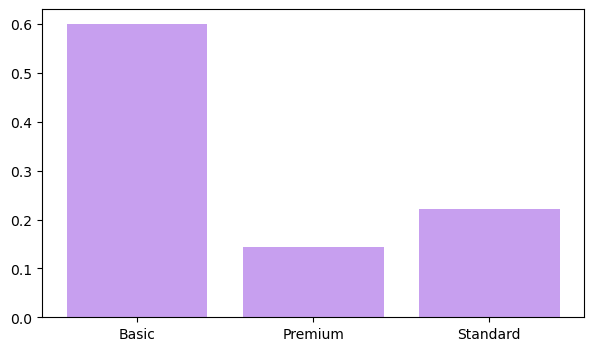

In [77]:
#2. Churn by plan type

churn_plan=df_visual.groupby('plan_type')['churn_flag'].mean()
plt.figure(figsize=(7,4))
plt.bar(churn_plan.index,churn_plan.values,color='xkcd:lavender')
plt.show()

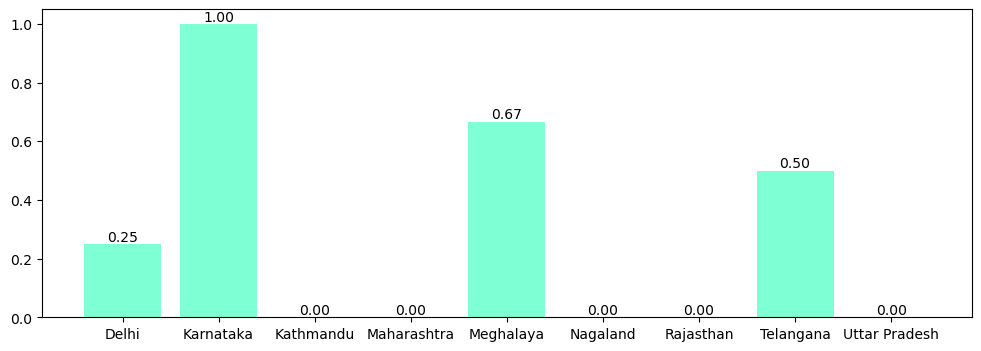

In [85]:
#3. Churn by state

churn_state=df_visual.groupby('state')['churn_flag'].mean()
plt.figure(figsize=(12,4))
bar=plt.bar(churn_state.index,churn_state.values,color='aquamarine')
plt.bar_label(bar, fmt='%.2f')
plt.show(bar)

In [92]:
#encoding- coverting str to numeric so that we can easily find correlation

df_encoded=df_visual[ ['plan_type', 'contract_type','churn_flag', 'escalations','churn_risk']]
df_encoded.head()

,plan_type,contract_type,churn_flag,escalations,churn_risk
0,Standard,Annual,0,0,low
1,Premium,Annual,1,1,high
2,Basic,Monthly,0,0,low
3,Premium,Annual,0,0,low
4,Standard,Monthly,1,1,high


In [93]:
#incorrect way of encoding- not done based on priority

categories=['plan_type','contract_type','churn_risk']
for col in categories:
    df_encoded[col]=df_encoded[col].astype('category').cat.codes

C:\Users\HP\AppData\Local\Temp\ipykernel_22252\760718108.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_encoded[col]=df_encoded[col].astype('category').cat.codes
C:\Users\HP\AppData\Local\Temp\ipykernel_22252\760718108.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_encoded[col]=df_encoded[col].astype('category').cat.codes
C:\Users\HP\AppData\Local\Temp\ipykernel_22252\760718108.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[ro

In [94]:
df_encoded.head()

,plan_type,contract_type,churn_flag,escalations,churn_risk
0,2,0,0,0,1
1,1,0,1,1,0
2,0,1,0,0,1
3,1,0,0,0,1
4,2,1,1,1,0


<Axes: >

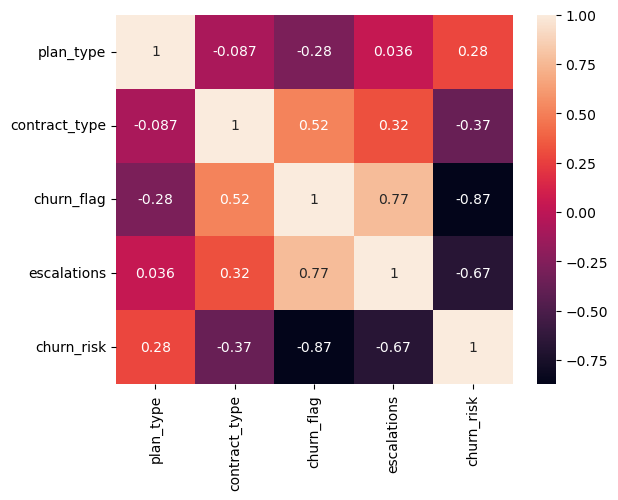

In [95]:
# coorelatoj between different categories resulting churn

sns.heatmap(df_encoded.corr(),annot=True)

In [98]:
df_visual['churn_risk'].unique()

array(['low', 'high', 'mid'], dtype=object)

In [110]:
# correct encoding - based on priority

df_encoded=df_visual[ ['plan_type', 'contract_type','churn_flag', 'escalations','churn_risk']]

order_mappings={
    'plan_type':['Basic','Standard','Premium'],
    'contract_type':['Monthly','Annual'],
    'churn_risk':['low','mid','high']
}

for col,order in order_mappings.items():
    df_encoded[col]=pd.Categorical(df_encoded[col].astype('category'),categories=order,ordered=True).codes

C:\Users\HP\AppData\Local\Temp\ipykernel_22252\2186789239.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_encoded[col]=pd.Categorical(df_encoded[col].astype('category'),categories=order,ordered=True).codes
C:\Users\HP\AppData\Local\Temp\ipykernel_22252\2186789239.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_encoded[col]=pd.Categorical(df_encoded[col].astype('category'),categories=order,ordered=True).codes
C:\Users\HP\AppData\Local\Temp\ipykernel_22252\2186789239.py:12: SettingWithCopyWarn

In [106]:
df_visual[ ['plan_type', 'contract_type','churn_flag', 'escalations','churn_risk']].head()

,plan_type,contract_type,churn_flag,escalations,churn_risk
0,Standard,Annual,0,0,low
1,Premium,Annual,1,1,high
2,Basic,Monthly,0,0,low
3,Premium,Annual,0,0,low
4,Standard,Monthly,1,1,high


In [111]:
df_encoded.head()

,plan_type,contract_type,churn_flag,escalations,churn_risk
0,1,1,0,0,0
1,2,1,1,1,2
2,0,0,0,0,0
3,2,1,0,0,0
4,1,0,1,1,2


<Axes: >

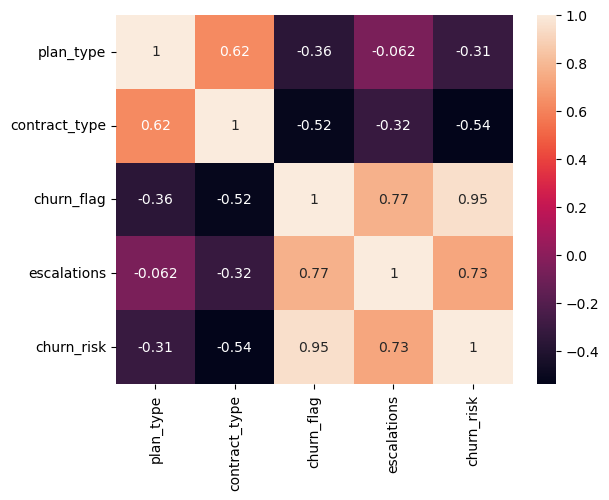

In [112]:
sns.heatmap(df_encoded.corr(),annot=True)

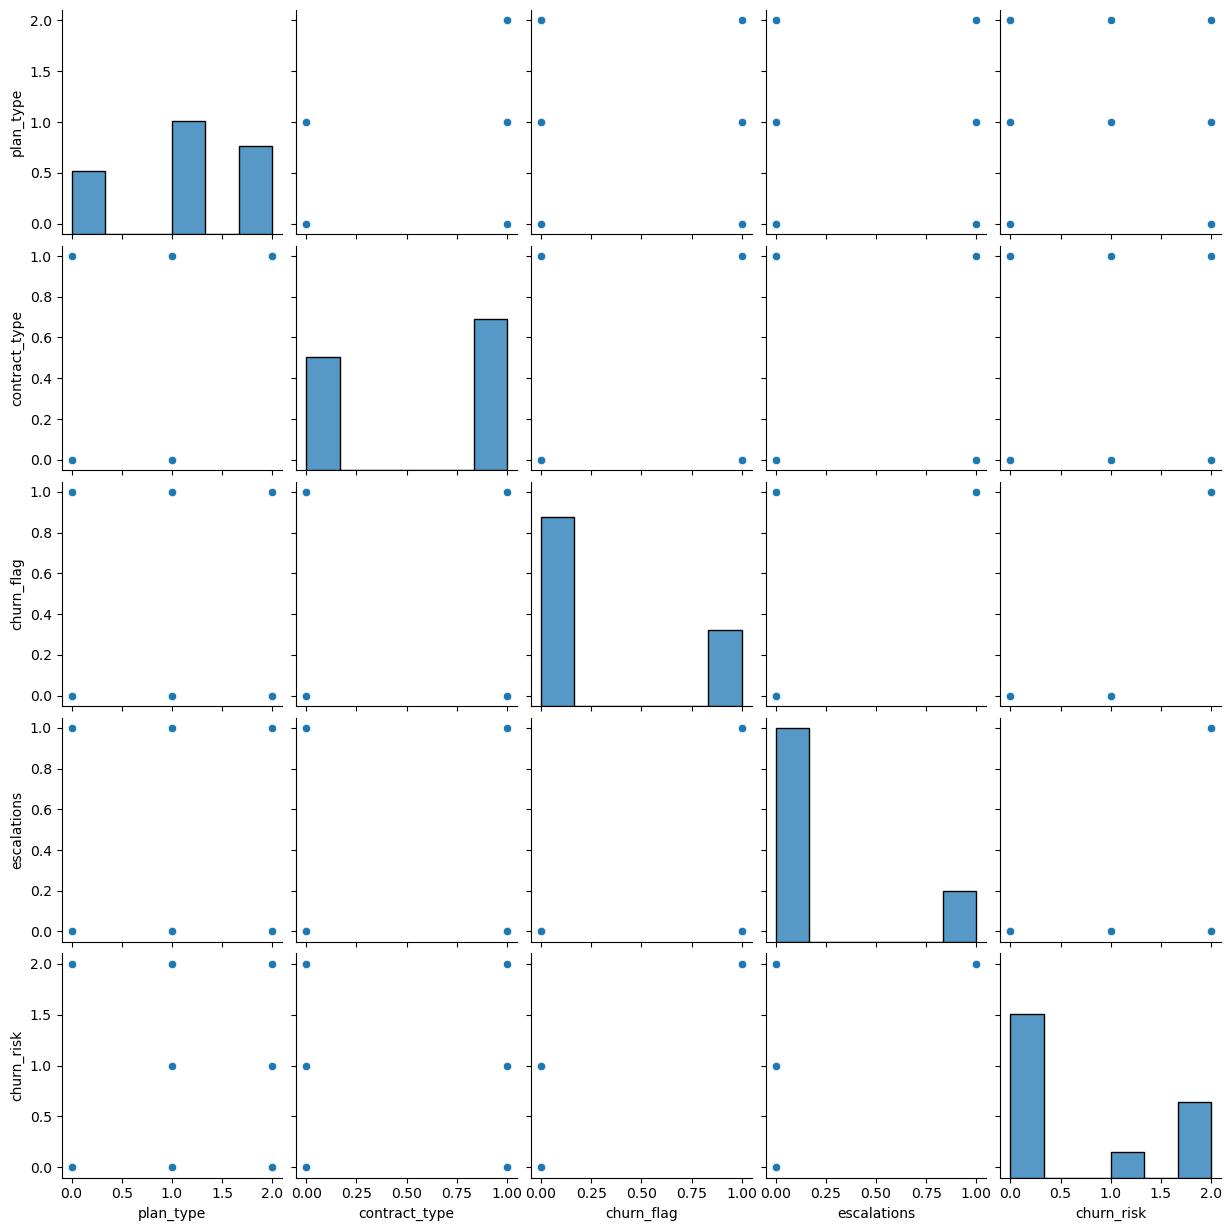

In [114]:
#pairplot- relationship in a dataset

sns.pairplot(df_encoded)

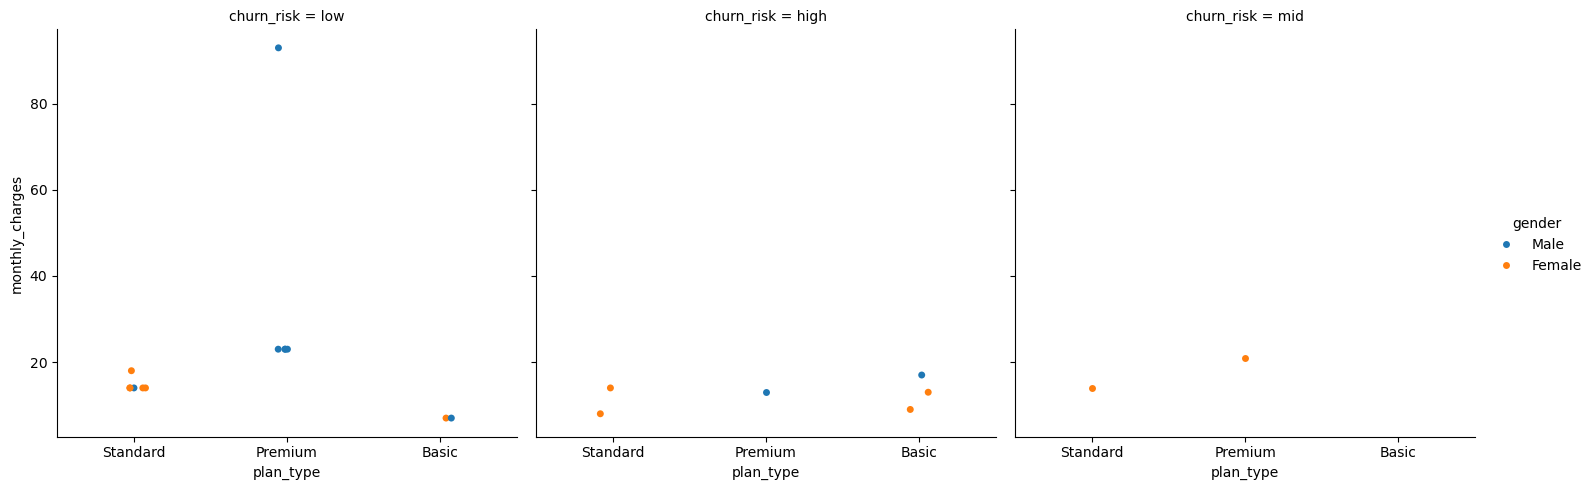

In [116]:
#catplot/faceplot- miulti diension comparision

sns.catplot(data=df_visual,
    x='plan_type',
    y='monthly_charges',
    hue='gender',
    col='churn_risk')

In [118]:
#pivot table

pd.pivot_table(
    df_visual,
    index='plan_type',
    values='churn_flag',
    aggfunc='mean'
)

,churn_flag
plan_type,
Basic,0.600000
Premium,0.142857
Standard,0.222222


In [120]:
pd.pivot_table(
    df_visual,
    index='plan_type',
    values=['monthly_charges','customerid','churn_flag'],
    aggfunc={
    'monthly_charges':'sum',
    'customerid':'nunique',
    'churn_flag':'mean'
    }
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


In [64]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'count', 'tenure_days',
       'churn_risk'],
      dtype='object')